In [26]:
# Cell 1: Load thư viện và dữ liệu Việt Nam
import pandas as pd
import numpy as np
import os
import torch
import warnings
warnings.filterwarnings("ignore")

# Đường dẫn đến file dữ liệu VN
path_vn_main = "data/processed/VN_data/full_vietnam_monthly.csv"
path_vn_weather = "data/processed/VN_data/full_weather_vietnam_monthly.csv"

# Đọc file
df_main = pd.read_csv(path_vn_main, sep=';')
df_weather = pd.read_csv(path_vn_weather)

print("Columns in main:", list(df_main.columns))
print("Columns in weather:", list(df_weather.columns))

# Merge dữ liệu (Giả sử dự trên Date/tháng và các cột định danh)
# Ta sẽ xem xét cách merge sao cho hợp lý sau khi thấy sơ bộ dữ liệu
display(df_main.head())
display(df_weather.head())


Columns in main: ['entity', 'date', 'series', 'is_aggregate_series', 'generation_twh', 'IPI_Value', 'CPI_Value', 'GDP_VND_Trillion', 'Oil_Price', 'FDI_Disbursed_Monthly(bilionUSD)', 'FDI_Registered_Monthly(bilionUSD)', 'gas_price', 'castlecoal_price', 'castlecoal_vol']
Columns in weather: ['date', 'humidity_mean', 'precip_mean', 'solar_mean', 'temp_mean']


,entity,date,series,is_aggregate_series,generation_twh,IPI_Value,CPI_Value,GDP_VND_Trillion,Oil_Price,FDI_Disbursed_Monthly(bilionUSD),FDI_Registered_Monthly(bilionUSD),gas_price,castlecoal_price,castlecoal_vol
0,Viet Nam,1/1/2019,Coal,False,9.63,134.05,100.1,7700.0,59.27,1.55,1.907,65.28,99.0,1.14K
1,Viet Nam,1/1/2019,Gas,False,4.12,134.05,100.1,7700.0,59.27,1.55,1.907,65.28,99.0,1.14K
2,Viet Nam,1/1/2019,Hydro,False,3.39,134.05,100.1,7700.0,59.27,1.55,1.907,65.28,99.0,1.14K
3,Viet Nam,1/1/2019,Other fossil,False,0.00,134.05,100.1,7700.0,59.27,1.55,1.907,65.28,99.0,1.14K
4,Viet Nam,1/1/2019,Solar,False,0.00,134.05,100.1,7700.0,59.27,1.55,1.907,65.28,99.0,1.14K


,date,humidity_mean,precip_mean,solar_mean,temp_mean
0,2019-01-01,78.634409,107.366667,401.016667,22.087097
1,2019-02-01,78.190476,30.700000,466.336667,24.680952
2,2019-03-01,78.408602,33.866667,522.160000,25.594624
3,2019-04-01,78.155556,109.033333,570.526667,28.315556
4,2019-05-01,80.451613,194.633333,585.696667,28.589247


In [27]:
# Cell 2: Merge dữ liệu và Tạo các feature cần thiết
import copy

# Loại bỏ 'Total Generation' trong df_main trước khi merge để tránh leak / tính toán dư thừa
if 'series' in df_main.columns:
    df_main['series'] = df_main['series'].astype(str).str.strip()
    df_main = df_main[~df_main['series'].str.casefold().eq('total generation')].copy()

df_vn = pd.merge(df_main, df_weather, on='date', how='left')

# Đổi lại tên cho khớp chuẩn của file gốc
df_vn = df_vn.rename(columns={
    'generation_twh': 'generation_TWh',
    'precip_mean': 'precipitation',
    'solar_mean': 'solar',
    'humidity_mean': 'humidity',
    'temp_mean': 'temperature'
})

# Loại bỏ các cột liên quan đến giá Gas và lượng Gas (do thiếu hụt dữ liệu lớn gây nhiễu)
cols_to_drop = ['gas_price', 'gas_vol']
if cols_to_drop:
    df_vn = df_vn.drop(columns=cols_to_drop, errors='ignore')
    print(f"Đã loại bỏ các cột Gas: {cols_to_drop}")

# Xử lý các điểm dữ liệu = 0 bằng một số epsilon cực nhỏ (giống code gốc)
# Điều này giúp hàm nội suy/scale không bị giãn quá đà do giá trị 0 tuyệt đối và cải thiện metrics dạng phần trăm (% WAPE)
if 'generation_TWh' in df_vn.columns:
    df_vn['generation_TWh'] = pd.to_numeric(df_vn['generation_TWh'], errors='coerce').fillna(0)
    df_vn['generation_TWh'] = df_vn['generation_TWh'].replace(0, 1e-4).clip(lower=1e-4)

# Đồng bộ Date và tạo time_idx, month...
df_vn['date'] = pd.to_datetime(df_vn['date'])
df_vn = df_vn.sort_values(['entity', 'series', 'date']).reset_index(drop=True)

min_date = df_vn['date'].min()
df_vn['time_idx'] = ((df_vn['date'].dt.year - min_date.year) * 12 + (df_vn['date'].dt.month - min_date.month)).astype(int)
df_vn['month'] = df_vn['date'].dt.month.astype(str)
df_vn['month_sin'] = np.sin(2 * np.pi * df_vn['date'].dt.month / 12.0)
df_vn['month_cos'] = np.cos(2 * np.pi * df_vn['date'].dt.month / 12.0)

# Tạo target lags và rolling cho generation_TWh (Giống premodel notebook)
def create_lag_roll(group):
    g = group.copy()
    g = g.sort_values('date')
    for lag in [1, 3, 6, 12]:
        g[f'target_lag_{lag}'] = g['generation_TWh'].shift(lag)
    for window in [3, 6, 12]:
        g[f'target_roll_mean_{window}'] = g['generation_TWh'].shift(1).rolling(window, min_periods=1).mean()
        g[f'target_roll_std_{window}'] = g['generation_TWh'].shift(1).rolling(window, min_periods=1).std().fillna(0)
    return g

df_vn = df_vn.groupby(['entity', 'series'], group_keys=False).apply(create_lag_roll)

# Cũn xử lý lag/roll có giá trị 0 thành 1e-4
lag_roll_cols = [c for c in df_vn.columns if 'lag' in c or 'roll' in c]
for c in lag_roll_cols:
    df_vn[c] = df_vn[c].replace(0, 1e-4).clip(lower=1e-4)

# Xử lý missing values bằng backfill / forwardfill theo group
cols_to_fill = ['precipitation', 'solar', 'humidity', 'temperature'] + \
               [c for c in df_vn.columns if 'target_lag' in c or 'target_roll' in c] + \
               ['IPI_Value', 'CPI_Value', 'GDP_VND_Trillion', 'Oil_Price', 'Oil_Change_Percent',
                'FDI_Disbursed_Monthly(bilionUSD)', 'FDI_Registered_Monthly(bilionUSD)']

for c in cols_to_fill:
    if c in df_vn.columns:
        df_vn[c] = df_vn.groupby(['entity', 'series'])[c].transform(lambda x: x.ffill().bfill())
        df_vn[c] = df_vn[c].fillna(0)

print(f"Tổng số records VN: {len(df_vn)}")
print(f"Các loại năng lượng: {df_vn['series'].unique()}")
display(df_vn.head(3))

Đã loại bỏ các cột Gas: ['gas_price', 'gas_vol']
Tổng số records VN: 432
Các loại năng lượng: ['Coal' 'Gas' 'Hydro' 'Other fossil' 'Solar' 'Wind']


,entity,date,series,is_aggregate_series,generation_TWh,IPI_Value,CPI_Value,GDP_VND_Trillion,Oil_Price,FDI_Disbursed_Monthly(bilionUSD),...,target_lag_1,target_lag_3,target_lag_6,target_lag_12,target_roll_mean_3,target_roll_std_3,target_roll_mean_6,target_roll_std_6,target_roll_mean_12,target_roll_std_12
0,Viet Nam,2019-01-01,Coal,False,9.63,134.05,100.10,7700.0,59.27,1.55,...,9.63,9.63,9.63,9.63,9.630,0.000100,9.630,0.000100,9.630,0.000100
1,Viet Nam,2019-02-01,Coal,False,9.90,108.37,100.80,7700.0,64.13,1.03,...,9.63,9.63,9.63,9.63,9.630,0.000100,9.630,0.000100,9.630,0.000100
2,Viet Nam,2019-03-01,Coal,False,8.43,134.77,99.79,7700.0,66.41,1.54,...,9.90,9.63,9.63,9.63,9.765,0.190919,9.765,0.190919,9.765,0.190919


In [28]:
# Cell 3: Chuẩn bị Dataset và Dataloader cho VN
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer

max_encoder_length = 36
max_prediction_length = 24  # Tăng độ dài dự đoán lên 24 tháng theo yêu cầu test lag
batch_size = 16

# Kiểm tra độ dài
series_lengths = df_vn.groupby(['entity', 'series'])['time_idx'].nunique().reset_index(name='n_steps')
min_required_length = max_encoder_length + max_prediction_length
valid_groups = series_lengths.loc[series_lengths['n_steps'] >= min_required_length, ['entity', 'series']]
df_vn_valid = df_vn.merge(valid_groups, on=['entity', 'series'], how='inner').copy()

training_cutoff = df_vn_valid['time_idx'].max() - max_prediction_length

# Phân chia feature tránh hiện tượng data leakage
known_candidates = [
    'time_idx', 'month_sin', 'month_cos',
    'precipitation', 'solar', 'humidity', 'temperature',
]

# Các biến không biết trước ở tương lai (bao gồm cả các lag/roll của target và các chỉ số kinh tế)
unknown_candidates = [
    'generation_TWh',
    'target_lag_1', 'target_lag_3', 'target_lag_6', 'target_lag_12',
    'target_roll_mean_3', 'target_roll_mean_6', 'target_roll_mean_12',
    'target_roll_std_3', 'target_roll_std_6', 'target_roll_std_12',
    # Các biến kinh tế của VN:
    'IPI_Value', 'CPI_Value', 'GDP_VND_Trillion',
    'Oil_Price', 'Oil_Change_Percent',
    'FDI_Disbursed_Monthly(bilionUSD)', 'FDI_Registered_Monthly(bilionUSD)'
]

known_reals = [c for c in known_candidates if c in df_vn_valid.columns]
unknown_reals = [c for c in unknown_candidates if c in df_vn_valid.columns]

training = TimeSeriesDataSet(
    df_vn_valid[lambda x: x.time_idx <= training_cutoff],
    time_idx='time_idx',
    target='generation_TWh',
    group_ids=['entity', 'series'],
    min_encoder_length=max_encoder_length // 2,
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    static_categoricals=['entity', 'series'],
    time_varying_known_categoricals=['month'],
    time_varying_known_reals=known_reals,
    time_varying_unknown_reals=unknown_reals,
    # SỬA LỖI MÔ HÌNH DỰ ĐOÁN THẤP: Bỏ param center=True đi để mô hình dùng lại chuẩn Softplus giống y hệt Base.
    # Hoặc để trống nếu file base là trống
    target_normalizer=GroupNormalizer(groups=['entity', 'series']),
    lags={'generation_TWh': [1, 2, 3, 6, 12]},
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

validation = TimeSeriesDataSet.from_dataset(training, df_vn_valid, predict=True, stop_randomization=True)

train_loader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_loader = validation.to_dataloader(train=False, batch_size=batch_size * 2, num_workers=0)

print("Đã tạo xong DataLoaders cho VN dataset")

Đã tạo xong DataLoaders cho VN dataset


In [29]:
# Cell 4: Transfer Learning - Load pretrained weights và Đóng băng (Freeze)
from pytorch_forecasting.metrics import QuantileLoss

# 1. Khởi tạo mô hình MỚI phù hợp với cấu trúc dữ liệu VN (có thêm features kinh tế)
tft_vn = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=1e-4,         # GIẢM LEARNING RATE xuống (từ 1e-3 -> 1e-4) để tránh làm hỏng các trọng số đã học (Catastrophic Forgetting)
    hidden_size=64,
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=32,
    loss=QuantileLoss(),
    log_interval=50,
    reduce_on_plateau_patience=3,
)
print("Đã khởi tạo model TFT mới với kiến trúc bao gồm các chỉ số kinh tế VN.")

# 2. Xử lý Transfer Learning: Load weights những layer trùng khớp từ Checkpoint tốt nhất
checkpoint_path = "checkpoint/tft_model_best.ckpt"
pretrained_dict = torch.load(checkpoint_path, map_location=tft_vn.device, weights_only=False)['state_dict']
model_dict = tft_vn.state_dict()

# Tìm các layer trùng khớp về Tên và Kích thước (Shape)
matched_dict = {k: v for k, v in pretrained_dict.items()
                if k in model_dict and v.shape == model_dict[k].shape}

# Cập nhật weight model mới bằng weight pre-trained
model_dict.update(matched_dict)
tft_vn.load_state_dict(model_dict)
print(f"Đã load thành công {len(matched_dict)} / {len(model_dict)} tensors từ pretrained model.")

# 3. Đóng băng (Freeze) các layer để Finetune
# HIỆN TƯỢNG QUÊN ĐỘT NGỘT (Catastrophic Forgetting):
# Khi đưa biến kinh tế mới vào (khởi tạo ngẫu nhiên), gradient trong những epoch đầu sẽ rất lớn và nhiễu
# Nếu Unfreeze toàn bộ, nhiễu này lan truyền đập nát bộ não LSTM & Attention đã train rất vất vả từ dữ liệu Global.
# GIẢI PHÁP:
# Khóa lại bộ não (LSTM, Attention). Giữ Variable Selection Network (VSN) mở để nó tự học cách
# "điều phối" và trọng số hóa các biến kinh tế mới, trước khi đưa vào LSTM.

layers_to_freeze = []

frozen_params = 0
unfrozen_params = 0

for name, param in tft_vn.named_parameters():
    freeze_this = any(f_name in name for f_name in layers_to_freeze) if layers_to_freeze else False
    if freeze_this:
        param.requires_grad = False
        frozen_params += param.numel()
    else:
        param.requires_grad = True
        unfrozen_params += param.numel()

print(f"---------------------------------------------------")
print(f"Tham số BỊ ĐÓNG BĂNG (Freezed): {frozen_params/1000:.1f} k")
print(f"Tham số FINETUNE (Unfreezed)  : {unfrozen_params/1000:.1f} k")
print(f"---------------------------------------------------")

Đã khởi tạo model TFT mới với kiến trúc bao gồm các chỉ số kinh tế VN.
Đã load thành công 638 / 743 tensors từ pretrained model.
---------------------------------------------------
Tham số BỊ ĐÓNG BĂNG (Freezed): 0.0 k
Tham số FINETUNE (Unfreezed)  : 522.3 k
---------------------------------------------------


In [30]:
# Cell 5: Tiến hành Fineturn (Train) model trên dữ liệu Việt Nam
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor

# Khởi tạo trainer với epoch nhỏ hơn (thường finetune không cần số bước quá lớn)
early_stop_callback = EarlyStopping(monitor='val_loss', min_delta=1e-5, patience=15, verbose=True, mode='min')
lr_logger = LearningRateMonitor()

trainer_vn = pl.Trainer(
    max_epochs=30,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[lr_logger, early_stop_callback],
    enable_model_summary=True,
)

# Bắt đầu Transfer Learning / Finetuning
print("Bắt đầu Finetune...")
trainer_vn.fit(tft_vn, train_dataloaders=train_loader, val_dataloaders=val_loader)

# Đánh giá val loss ngay sau khi train xong
print("Đánh giá sau Finetune...")
metrics = trainer_vn.validate(tft_vn, dataloaders=val_loader)
print("Kết quả Finetune (VN dataset):", metrics)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Bắt đầu Finetune...


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │     97 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  2.1 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 21.2 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  236 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 57.2 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  8.3 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    128 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 10.4 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    455 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 522 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 522 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 787                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Monitored metric val_loss did not improve in the last 15 records. Best score: 0.707. Signaling Trainer to stop.


Output()

Đánh giá sau Finetune...


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_MAE          │     1.02581787109375      │
│         val_MAPE          │     36.34300231933594     │
│         val_RMSE          │    1.8114122152328491     │
│         val_SMAPE         │    0.5610697269439697     │
│         val_loss          │    0.8062236905097961     │
└───────────────────────────┴───────────────────────────┘

Kết quả Finetune (VN dataset): [{'val_loss': 0.8062236905097961, 'val_SMAPE': 0.5610697269439697, 'val_MAE': 1.02581787109375, 'val_RMSE': 1.8114122152328491, 'val_MAPE': 36.34300231933594}]


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightn

--- KẾT QUẢ ĐÁNH GIÁ (TẬP VALIDATION VN) ---
Validation MAE : 1.0258
Validation RMSE: 1.8114
Validation WAPE: 25.1807%
Validation R2  : 0.8314


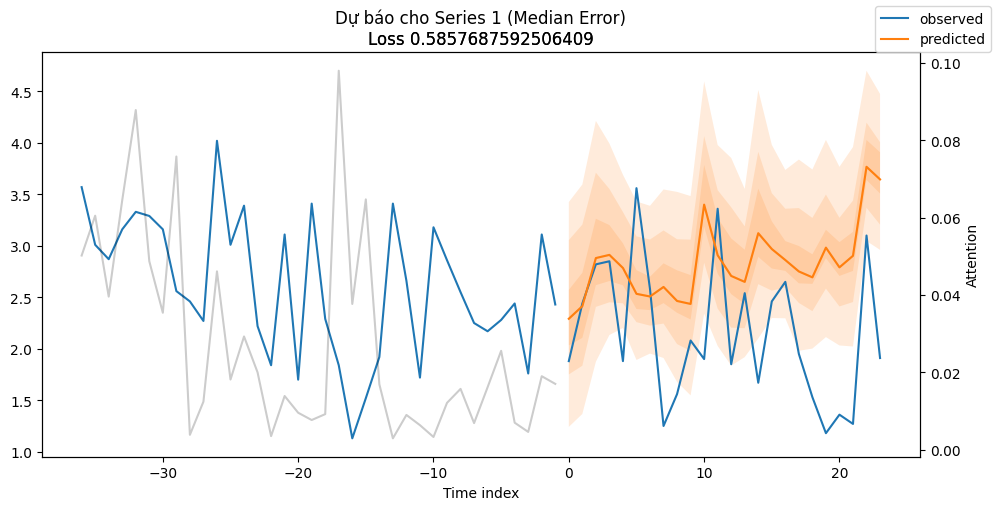

In [31]:
# Cell 6: Đánh giá chi tiết (Metrics & Biểu đồ) sau khi Transfer Learning
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Tắt gradient khi dự báo
torch.set_grad_enabled(False)
raw_pred_obj = tft_vn.predict(val_loader, mode='raw', return_x=True)

if hasattr(raw_pred_obj, 'output'):
    raw_predictions = raw_pred_obj.output
    x = getattr(raw_pred_obj, 'x', None)
elif isinstance(raw_pred_obj, tuple):
    raw_predictions = raw_pred_obj[0]
    x = raw_pred_obj[1] if len(raw_pred_obj) > 1 else None
else:
    raw_predictions = raw_pred_obj
    x = None

point_pred_obj = tft_vn.predict(val_loader, mode='prediction')
point_predictions = point_pred_obj.output if hasattr(point_pred_obj, 'output') else point_pred_obj

actuals = torch.cat([y[0] for _, y in iter(val_loader)])

# Tính toán các metrics
mae = (actuals - point_predictions).abs().mean().item()
rmse = torch.sqrt(((actuals - point_predictions) ** 2).mean()).item()
wape = ((actuals - point_predictions).abs().sum() / (actuals.abs().sum() + 1e-8)).item() * 100

y_true_np = actuals.detach().cpu().numpy().reshape(-1)
y_pred_np = point_predictions.detach().cpu().numpy().reshape(-1)
r2 = r2_score(y_true_np, y_pred_np)

print(f"--- KẾT QUẢ ĐÁNH GIÁ (TẬP VALIDATION VN) ---")
print(f'Validation MAE : {mae:.4f}')
print(f'Validation RMSE: {rmse:.4f}')
print(f'Validation WAPE: {wape:.4f}%')
print(f'Validation R2  : {r2:.4f}')

# Vẽ biểu đồ: Chọn chuỗi có lỗi trung vị để vẽ tránh bias
if len(actuals) > 0:
    err_per_series = (actuals - point_predictions).abs().mean(dim=1)
    idx_plot = int(torch.argsort(err_per_series)[len(err_per_series) // 2].item())

    if x is not None:
        fig, ax = plt.subplots(figsize=(10, 5))
        _ = tft_vn.plot_prediction(x, raw_predictions, idx=idx_plot, add_loss_to_title=True, ax=ax)
        plt.title(f"Dự báo cho Series {idx_plot} (Median Error)\n" + ax.get_title())
        plt.show()

In [32]:
# Cell 7: Lưu cấu hình và model sau Transfer Learning
import shutil
import os

# Tạo thư mục checkpoint nếu chưa có
os.makedirs("checkpoint", exist_ok=True)

model_save_path = "checkpoint/tft_vn_model_best.ckpt"

# Lưu state cuối cùng
trainer_vn.save_checkpoint("checkpoint/tft_vn_model_latest.ckpt")
print("Đã lưu mô hình mới nhất (cuối quá trình Finetune) tại: checkpoint/tft_vn_model_latest.ckpt")

# Nếu EarlyStopping chạy và trích xuất được model tốt nhất (dựa trên val_loss thấp nhất)
if trainer_vn.checkpoint_callback and getattr(trainer_vn.checkpoint_callback, 'best_model_path', None):
    best_path = trainer_vn.checkpoint_callback.best_model_path
    if os.path.exists(best_path):
        print(f"File checkpoint tốt nhất (tự động lưu bởi Lightning): {best_path}")

        # Copy ra thư mục checkpoint cho dễ tìm
        shutil.copy(best_path, model_save_path)
        print(f"Đã copy mô hình tốt nhất (Finetuned) sang: {model_save_path}")
else:
    print("Không tìm thấy checkpoint tự động của best model. Bạn có thể dùng bản tft_vn_model_latest.ckpt ở trên.")

# Để load lại dùng dự báo ở file khác:
# from pytorch_forecasting import TemporalFusionTransformer
# loaded_tft_vn = TemporalFusionTransformer.load_from_checkpoint("checkpoint/tft_vn_model_best.ckpt")

`weights_only` was not set, defaulting to `False`.


Đã lưu mô hình mới nhất (cuối quá trình Finetune) tại: checkpoint/tft_vn_model_latest.ckpt
File checkpoint tốt nhất (tự động lưu bởi Lightning): c:\Users\ADMIN\Downloads\MODEL_TFT\lightning_logs\version_48\checkpoints\epoch=18-step=247.ckpt
Đã copy mô hình tốt nhất (Finetuned) sang: checkpoint/tft_vn_model_best.ckpt
